# Логистическая регрессия. Нейронные сети

Добро пожаловать в первую лабораторную работу по нейронным сетям.

Методы машинного обучения и искусственного интеллекта обычно предназначены для решения 2х основных задач: классификации и регрессии.

Задача **классификации** заключается в определение принадлежности объекта к одному из заранее определенных классов. Простейший пример такой задачи - классификация изображений цифр: нужно определить, изображение какой цифры (от 0 до 9) представлена модели в текущий момент. В случае классификации классы являются дискретными.

Задача **регрессии** - попытка восстановить недостающие значения временного ряда или спрогнозировать его. Примером такой задачи может быть прогноз погоды. прогнозируемые данные в этом случае, как правило, вещественные и непрерывные.

В этой лабораторной работе мы будем решать задачу бинарной (когда у нас есть только 2 возможных класса) **классификации**. Работа знакомит с моделью логистической регрессии - это алгоритм классификации, а не регрессии, как можно подумать из названия! Данный алгоритм был разработан задолго до появления компьютеров, однако, до сих пор остается востребованным благодаря своей простоте и уникальности.

**Указания к выполнению:**
- Не используйте циклы (for/while) в коде, если в задании не сказано об обратном.

**Задачи лабораторной №2:**
- Создать основные методы для обучающения нейронной сети:
    - Инициализация параметров
    - Вычисление функции ошибки модели и ее градиента
    - Использование оптимизационного алгоритма (градиентный спуск)
- Обучить нейронную сеть

Логистическая регрессия относится к статистическим моделям, так как она не только определяет класс объекта, но еще и рассчитывает вероятность принадлежности объекта данному классу (предсказывает вероятность возникновения события). Эта модель часто применяется в задачах классификации на основе линейных моделей. Она применима как для бинарной классификации (когда у нас всего 2 разных класса), так и для многоклассовой (больше 2х классов) – в форме мультиномиальной логистической регрессии.

Таким образом, бинарная логистическая модель применяется для оценивания вероятности принадлежности объекта к одному из двух классов по переданным на вход признакам данного объекта.


# 1. Подключение библиотек

В начале работы необходимо импортировать все необходимые библиотеки для выполнения задания:
- numpy - это библиотека для научных расчетов, мы знакомились с ней в прошлой лабораторной работе
- h5py - библиотека для работы с данными в форматах: .hdf, .h4, .hdf4, .he2, .h5, .hdf5 или .he5
- matplotlib - библиотека для визуализации данных
- PIL - это библиотека для работы с растровыми изображениями
- scipy - библиотека, предназначенная для выполнения научных и инженерных расчётов

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import scipy
from PIL import Image
from scipy import ndimage
from utils import load_dataset

%matplotlib inline

# 2. Анализ входных данных

Входной набор данных представляет собой изображения, размеченные на два класса - "кошки" (y=1) и "не кошки" (y=0), и разделяется на:
* обучающая выборка - `m_train`,
* тестовая выбборка - `m_test`.
Каждое изображение размером `(num_py, num_px)` имеет 3 канала RGB.

**Обратите внимание**, что каждому примеру из обучающей и тестовой выборки соответсвует **целевое значение** $y \in \{0,1\}$. Именно таких выходов мы будем требовать при обучении модели.

**Задание 2.1:** построить с помощью алгоритма логистической регрессии бинарный классификатор для классификации описанного выше набора изображений.

Запустите код ниже, чтобы загрузить датасет с помощью вспомогательных функций, описанных в библиотеке `utils.py`

In [ ]:
# Загрузка наборов данных
train_set_x_orig, train_set_y, test_set_x_orig, test_set_y, classes = load_dataset()

В датасетах train_set_x_orig и test_set_x_orig каждая строка представляет собой изображение.

**Задание 2.2:** Визуализируйте некоторые примеры, меняя значение index и выполняя код. Объясните, как получить класс изображения.


y = [1], это класс 'cat' изображений.


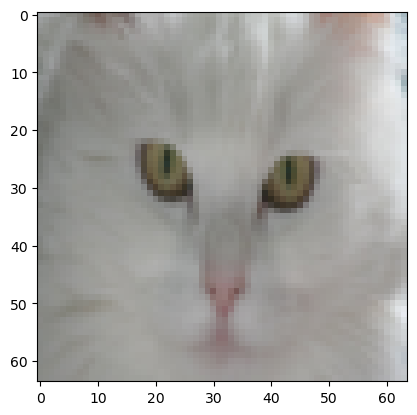

In [ ]:
# Пример изображения
index = 50
plt.imshow(train_set_x_orig[index])
print ("y = " + str(train_set_y[:, index]) + ", это класс '" + classes[np.squeeze(train_set_y[:, index])].decode("utf-8") + "' изображений.")

y = [0], это класс 'non-cat' изображений.


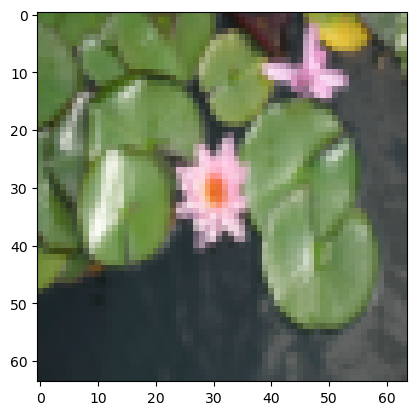

In [ ]:
index = 26
plt.imshow(train_set_x_orig[index])
print ("y = " + str(train_set_y[:, index]) + ", это класс '" + classes[np.squeeze(train_set_y[:, index])].decode("utf-8") + "' изображений.")

Найдите значения следующих парамеров датасета:
* `m_train` - число обучающих примеров
* `m_test` - число тестовых примеров
* `num_px` - ширина изображения
* `num_py` - высота изображения

`train_set_x_orig` является numpy-тензором размером `(m_train, num_py, num_px, 3)`.

**Задание 2.3:** Выведите на экран форму(shape) тензоров, поясните полученные значения.

In [ ]:
m_train = train_set_x_orig.shape[0]
m_test = test_set_x_orig.shape[0]
num_px = train_set_x_orig.shape[2]
num_py = train_set_x_orig.shape[1]

print ("Количество обучающих примеров: m_train = " + str(m_train))
print ("Количество тестовых примеров: m_test = " + str(m_test))
print ("Ширина изображения: num_px = " + str(num_px))
print ("Высота изображения: num_py = " + str(num_py))
print ("Форма массива изображения: (" + str(num_py) + ", " + str(num_px) + ", 3)")
print ("train_set_x shape: " + str(train_set_x_orig.shape))
print ("train_set_y shape: " + str(train_set_y.shape))
print ("test_set_x shape: " + str(test_set_x_orig.shape))
print ("test_set_y shape: " + str(test_set_y.shape))

Количество обучающих примеров: m_train = 209
Количество тестовых примеров: m_test = 50
Ширина изображения: num_px = 64
Высота изображения: num_py = 64
Форма массива изображения: (64, 64, 3)
train_set_x shape: (209, 64, 64, 3)
train_set_y shape: (1, 209)
test_set_x shape: (50, 64, 64, 3)
test_set_y shape: (1, 50)


Сначала измените форму тензора изображения (num_py, num_px, 3) на numpy-тензор формой (num_py $*$ num_px $*$ 3, 1), где каждый столбец будет соотвествовать изображению.

Преобразование вектора X размером (a,b,c,d) в матрицу X_flatten размером (b$*$c$*$d, a) можно осуществить следующим образом:
```python
X_flatten = X.reshape(X.shape[0], -1).T      # X.T is the transpose of X
```

In [ ]:
train_set_x_flatten = train_set_x_orig.reshape(train_set_x_orig.shape[0], -1).T
test_set_x_flatten = test_set_x_orig.reshape(test_set_x_orig.shape[0], -1).T

print ("train_set_x_flatten shape: " + str(train_set_x_flatten.shape))
print ("train_set_y shape: " + str(train_set_y.shape))
print ("test_set_x_flatten shape: " + str(test_set_x_flatten.shape))
print ("test_set_y shape: " + str(test_set_y.shape))

train_set_x_flatten shape: (12288, 209)
train_set_y shape: (1, 209)
test_set_x_flatten shape: (12288, 50)
test_set_y shape: (1, 50)


In [ ]:
# Проверка правильности измнения формы массивов
assert np.array_equal(train_set_x_flatten[0:5,0],np.array([17, 31, 56, 22, 33]))

Для представления изображений в цветовой системе RGB значение каждого пикселя представляет собой вектор из трёх чисел в диапазоне от 0 до 255.

Было бы проблематично передать в нейронную сеть значения, имеющие самые разные диапазоны. Сеть, конечно, сможет автоматически адаптироваться к таким разнородным данным, однако это усложнит процесс обучения.

Для текущего набора изображений выберем функцию минимакс, т.е. в нашем случае просто разделим каждую строку набора данных на 255 (максимальное возможное значение пиксельного канала).

In [ ]:
train_set_x = train_set_x_flatten/255.
test_set_x = test_set_x_flatten/255.

YOUR ANSWER HERE

<font color='blue'>
**Подведём промежуточные итоги:**

Распространенными шагами предварительной обработки данных являются:
- Определение числа и исходных размеров входных данных (m_train, m_test, num_px, ...)
- Измение формы набора данных таким образом, чтобы каждый пример представлял собой вектор-столбец
- Нормализация данных

## 3 - Модель нейронной сети ##

Многослойные персептроны (MLP) также называют простыми нейронными сетями прямого распространения, а иногда и просто нейронными сетями. MLP можно рассматривать как обобщение линейных моделей, которое прежде чем прийти к решению выполняет несколько этапов обработки данных. Следующее изображение объясняет, почему **Логистическая регрессия является очень простой нейронной сетью!**

<img src="images/log_reg.png" style="width:650px;height:400px;">

**Математическая формулировка**:

Сформулируем работу модели для одного объекта из обучающей выборки $x^{(i)}$:

$$z^{(i)} = w^T x^{(i)} + b \tag{1},$$

где $x^{(i)}$ - вектор признаков $i$-ого объекта,

$w^T$ - вектор весов признаков,

$b$ - свободный коэффициент (bias),

$z^{(i)}$ - результат линейной комбинации признаков $i$-ого объекта с соответсвующими весами.


В результате на выходе модели получим:

$$\hat{y}^{(i)} = a^{(i)} = sigmoid(z^{(i)})\tag{2},$$

где $\hat{y}^{(i)} = a^{(i)}$ - выходное значение модели в ответ на входной объект $x^{(i)}$.


**Оценка качества построенной модели**:

Как мы уже обсуждали, настройка модели заключается в подборе вектора весов $w$. Для того, чтобы определить, как корректировать веса, нам нужно рассчитать ошибку модели на обучающих примерах. В модели **логистической регрессии** функция оценки качества модели $\mathcal{L1}$ будет такой:

$$\mathcal{L1}(a^{(i)}, y^{(i)}) =  y^{(i)}  \ln(a^{(i)}) + (1-y^{(i)} )  \ln(1-a^{(i)})\tag{3},$$

где $y^{(i)}$ - целевое значение (или желаемый выход сети),
$a^{(i)}$ - выходное значение модели.


Давайте разберем, действительно ли оценка возрастает, если модель угадывает класс объекта правильно.

Рассмотрим 4 примера:
1. $y^{(0)} = 1, a^{(0)} = 0.01$ - в этом случае модель сильно ошиблась, она выдала значение близкое к 0;
2. $y^{(1)} = 1, a^{(1)} = 0.8$ - в этом случае модель сработала правильно, угадав класс 1;
3. $y^{(2)} = 0, a^{(2)} = 0.8$ - в этом случае модель сильно ошиблась, она выдала значения близкие к 1;
4. $y^{(3)} = 0, a^{(3)} = 0.1$ - в этом случае модель сработала правильно, угадав класс 0.

Теперь рассчитаем функцию качества для наших примеров:
1. $\mathcal{L1}(a^{(0)}, y^{(0)}) = 1*ln(0.01) +0*ln(0.99) = -4.6$
2. $\mathcal{L1}(a^{(1)}, y^{(1)}) = 1*ln(0.8)+0*ln(0.2) = -0.22$
3. $\mathcal{L1}(a^{(2)}, y^{(2)}) = 0*ln(0.8)+1*ln(0.2) = -1.6$
4. $\mathcal{L1}(a^{(3)}, y^{(3)}) = 0*ln(0.9)+1*ln(0.1) = -0.1$

Таким образом, чем ближе выход модели к истинному значению, тем больше значение функции качества на этом примере.

Как выглядит рассматриваемая фукнция потерь можно посмотреть по ссылке:
https://sisyphus.gitbook.io/project/deep-learning-basics/basics/multi-class-and-cross-entropy-loss

В этой работе мы собирается минимизировать функцию **потерь** (ошибок) модели $\mathcal{L}$ на объекте $x^{(i)}$, поэтому добавим минус к только что заданной функции оценки качества:

$$\mathcal{L}(a^{(i)}, y^{(i)}) =  - y^{(i)}  \ln(a^{(i)}) - (1-y^{(i)} )  \ln(1-a^{(i)})\tag{3} \longrightarrow min,$$

На самом деле в качестве функции ошибки можно применять различные функции, например считать среднеквадратичную ошибку (MSE), или модуль разности целевого и правильного ответа. Применение функции ошибки такого вида определяет название метода - **логистическая регрессия**. На выходе она дает оценку вероятности того, что объект принадлежит классу 1.

Полная функция ошибки модели на всей обучающей выборке рассчитывается путем суммирования всех значений функции ошибки на каждом примере обучения:
$$ J = \frac{1}{m} \sum_{i=1}^m \mathcal{L}(a^{(i)}, y^{(i)})\tag{6}$$

При обучении сети нам необходимо минимизировать функцию ошибки, т.е. найти ее минимум. Это можно сделать, рассчитав градиент функции ошибки.

**Задачи**:
В этом задании необходимо выполнить следующие шаги:
- инициализировать параметры модели;
- обучить модель, минимизировав функцию потерь;
- использовать обученную модель для прогнозирования (на тестовом наборе);
- проанализировать результаты и сделать вывод.

YOUR ANSWER HERE

YOUR ANSWER HERE

## 4 - Построение алгоритма ##

Основными шагами для для построения нейронной сети являются:
1. Определение архитектуры сети (число входных признаков, нейронов)
2. Инициализация параметров сети
3. Обучение в виде цикла:
    - Рассчет ошибки итерации (прямое распространение ошибки)
    - Расчет градиента ошибки (обатное распространение ошибки)
    - Обновление параметров сети (градиентный спуск)

Вам необходимо реализовать пункты 1-3 отдельными функциями и затем соединить их в функции `model()`.

### 4.1 - Сигмоидальная функция активации

**Задание 2.5**: Реализуйте сигмоидальную функцию `sigmoid()`, вычисляющую $sigmoid( w^T x + b) = \frac{1}{1 + e^{-(w^T x + b)}}$. Используйте np.exp().

In [ ]:
# Функция активации: sigmoid

def sigmoid(z):
    s = 1 / (1 + np.exp(-z))
    return s

In [ ]:
assert sigmoid(np.array([0,2]))[0] == 0.5
assert round(sigmoid(np.array([0,2]))[1], 6) == 0.880797

### 4.2 - Инициализация параметров
**Задание 2.6:** Реализуйте инициализацию весовых коэффициентов нулями, используя np.zeros().

In [ ]:
# Инициализация нулями: initialize_with_zeros

def initialize_with_zeros(dim):

    w = np.zeros((dim,1))
    b = 0

    assert(w.shape == (dim, 1))
    assert(isinstance(b, float) or isinstance(b, int))

    return w, b

In [ ]:
dim = 2
w, b = initialize_with_zeros(dim)
assert np.array_equal(w,np.array([[0.],[0.]]))
assert np.array_equal(b,0)

### 4.3 - Прямое распространение ошибки

Для того, чтобы рассчитать значение функции ошибки нужно реализовать функцию прямого прохода данных по сети.

**Задание 2.7:** Реализуйте функцию `propagate()`, которая вычисляет функцию потерь.

**Подсказки**:

Прямое распространение сигнала:
- Предъявление очередного экземпляра Х из обучающей выборки на вход нейронной сети;


- Вычисление выходного сигнала модели $A = \sigma(w^T X + b) = (a^{(1)}, a^{(2)}, ..., a^{(m-1)}, a^{(m)})$;


- Определение ошибки модели: $J = -\frac{1}{m}\sum_{i=1}^{m}y^{(i)}\ln(a^{(i)})+(1-y^{(i)})\ln(1-a^{(i)})$.

In [ ]:
def propagate(w, b, X, Y):
    m = X.shape[1]
    A = sigmoid(np.dot(w.T, X) + b)
    cost = -1/m * np.sum(Y * np.log(A) + (1-Y) * np.log(1-A))
    return cost

In [ ]:
w, b, X, Y = np.array([[1],[2]]), 2, np.array([[1,2],[3,4]]), np.array([[1,0]])
cost = propagate(w, b, X, Y)

assert np.round(cost) == 6

**Вопрос 2.3:** Объясните, что происходит в первой строчке кода предыдущей ячейки.

# Часть 2

### 4.4 - Обратное распространение ошибки

Наиболее известный алгоритм обучения нейронной сети - метод обратного распространения ошибки.
Данный алгоритм используется для минимизации отклонения реальных значений выходных сигналов нейронной сети от требуемых.

**Задание 2.8:** Реализуйте функцию `grad_propagate()`, которая вычисляет функцию стоимости и ее градиент.

**Подсказки**:

Прямое распространение сигнала:
- Предъявление очередного экземпляра Х из обучающей выборки на вход нейронной сети
- Вычисление выходного сигнала $A = \sigma(w^T X + b) = (a^{(1)}, a^{(2)}, ..., a^{(m-1)}, a^{(m)})$
- Определение величин ошибок нейронов выходного слоя: $J = -\frac{1}{m}\sum_{i=1}^{m}y^{(i)}\log(a^{(i)})+(1-y^{(i)})\log(1-a^{(i)})$


**Подробнее рассмотрим процесс вычисления градиента для логистической регрессии для одного примера:**


<img src="images/intuition.png" style="width:600px;">

**Процесс передачи данных можно представить в виде 3х основных этапов:**
1. Результат $z$ - линейной комбинации входных призаков $x$ с весами $w$ и смещением $b$;
2. Расчет $a$ - сигмоидальной функции активации $\sigma$;
3. Оценка фукции ошибки $\mathcal{L}$.

$$ \mathcal{L} = -y^{(i)}\ln(a^{(i)})-(1-y^{(i)})\ln(1-a^{(i)}).$$

**Расчет градиента происходит в обратном направлении:**


1. Оценка производной функции ошибки $\mathcal{L}$ по выходу $a$:

$$ \frac{\partial \mathcal{L}}{\partial a} = -\frac{y}{a}+\frac{1-y}{1-a}.$$

Напомним, что производная $$(ln(x))' = \frac{1}{x}$$


2. Оценка производной функции ошибки $\mathcal{L}$ по $z$ по правилу нахождения производной сложной функции (правило цепочки):

$$ \frac{\partial \mathcal{L}}{\partial z} = \frac{\partial \mathcal{L}}{\partial a}\frac{\partial a}{\partial z} = {(-\frac{y}{a}+\frac{1-y}{1-a}})a(1-a)=(a-y)$$


3. Оценка производной функции ошибки $\mathcal{L}$ по весам $w$ и смещению $b$:

$$ \frac{\partial \mathcal{L}}{\partial w} = \frac{\partial \mathcal{L}}{\partial a}\frac{\partial a}{\partial z} \frac{\partial z}{\partial w}= (a-y)x$$

$$ \frac{\partial \mathcal{L}}{\partial b} = \frac{\partial \mathcal{L}}{\partial a}\frac{\partial a}{\partial z} \frac{\partial z}{\partial b}= (a-y).$$

#### Расчет градиента функции потерь по всем примерам обучающей выборки можно записать в матричном виде:

Расчет градиента функции потерь по значениям весов $w$  и смещения $b$ осуществляется по следующим формулам:

$$ \frac{\partial J}{\partial w} = \frac{1}{m}X(A-Y)^T\tag{7},$$

где $m$ - количество объектов в обучающей выборке;

$X$ - матрица признаков объектов (которая подается на вход сети);

$A$ - вектор выходных значений модели для всех объектов обучающей выборки;

$Y$ - вектор целевых значений для всех объектов обучающей выборки.

$$ \frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^m (a^{(i)}-y^{(i)})\tag{8},$$

где $m$ - количество объектов в обучающей выборке;
$a^{(i)}$ - выходное значение модели для объекта с индексом $i$ обучающей выборки;
$y^{(i)}$ - целевое значение для объекта с индексом $i$ обучающей выборки.

In [ ]:
# Прямое и обратное распространение ошибки: grad_propagate

def grad_propagate(w, b, X, Y):
    m = X.shape[1]
    A = 1 / (1 + np.exp(-(np.dot(w.T, X) + b)))
    cost = - 1 / m * np.sum(Y * np.log(A) + (1 - Y) * np.log(1 - A))
    dw = 1 / m * np.dot(X, (A - Y).T)
    db = 1 / m * np.sum(A - Y)

    assert(dw.shape == w.shape)
    assert(db.dtype == float)
    cost = np.squeeze(cost)
    assert(cost.shape == ())

    grads = {"dw": dw,
             "db": db}

    return grads, cost

In [ ]:
w, b, X, Y = np.array([[1],[2]]), 2, np.array([[1,2],[3,4]]), np.array([[1,0]])
grads, cost = grad_propagate(w, b, X, Y)

assert np.round(grads["dw"])[0] == 1
assert np.round(grads["dw"])[1] == 2
assert np.round(grads["db"],1) == 0.5
assert np.round(cost) == 6

### 4.4 - Корректировка весов

Значение производной в точке характеризует скорость изменения фукции в этой точке, а точнее скорость её возрастания. Так как нам нужно минимизировать функцию ошибок, то двигаться нужно в обратном направлении - направлении убывания функции или антиградиента.

**Задание 2.9:** Напишите ниже функцию обучения, которая корректирует веса $w$ и смещения $b$ при минимизации функции потерь выхода $J$. Для параметра $w$ реализуйте правило обновления $ w = w - \alpha \text{ } \frac{\partial J}{\partial w}$, где $\alpha$ - скорость обучения. Аналогичную формулу реализуйте для смещения $b$.

In [ ]:
# Функция оптимизации: optimize

def optimize(w, b, X, Y, num_iterations, learning_rate, print_cost = False):
    costs = []
    for i in range(num_iterations):

        # Вычисление градиента и функции стоимости
        m = X.shape[1]
        A = 1 / (1 + np.exp(-(np.dot(w.T, X) + b)))
        cost = - 1 / m * np.sum(Y * np.log(A) + (1 - Y) * np.log(1 - A))
        dw = 1 / m * np.dot(X, (A - Y).T)
        db = 1 / m * np.sum(A - Y)

        # обновление весов
        w = w - learning_rate * dw
        b = b - learning_rate * db

        if i % 100 == 0:
            costs.append(cost)

        if print_cost and i % 100 == 0:
            print ("Cost after iteration %i: %f" %(i, cost))

    params = {"w": w,
              "b": b}
    grads = {"dw": dw,
             "db": db}
    return params, grads, costs

In [ ]:
params, grads, costs = optimize(w, b, X, Y, num_iterations= 100, learning_rate = 0.009, print_cost = False)

pw = params["w"]
pb = params["b"]
assert np.round(pw,5)[0] == 0.11246
assert np.round(pw,5)[1] == 0.23107
assert np.round(pb,5) == 1.55930

assert np.round(grads["dw"],5)[0] == 0.90158
assert np.round(grads["dw"],5)[1] == 1.76251
assert np.round(grads["db"],5) == 0.43046

**Задание 2.10:** Предыдущая функция обучения позволяет подобрать параметры весов w и смещений b нейронов сети. Используйте обученные параметры для предсказания класса экземпляра входных данных X. Реализуйте функцию `predict()`, состоящую из следующих шагов:

1. Вычисление $\hat{Y} = A = \sigma(w^T X + b)$

2. Присвоение метки класса для значения a: если значение функции активации <= 0.5, то 0, иначе 1 (активация > 0.5). запись результата классификации в вектор `Y_prediction`.

In [ ]:
# Функция классификации: predict

def predict(w, b, X):
    m = X.shape[1]
    Y_prediction = np.zeros((1,m))
    w = w.reshape(X.shape[0], 1)

    # Вычислите вектор "A"
    A = 1 / (1 + np.exp(-(np.dot(w.T, X) + b)))

    # Произведите классификацию с помощью порогового значения 0.5
    Y_prediction = np.where(A <= 0.5, 0, 1)

    assert(Y_prediction.shape == (1, m))

    return Y_prediction

In [ ]:
assert np.array_equal(predict(w, b, X),np.array([[1.,1.]]))

<font color='blue'>
**Промежуточные итоги:**

Основными шагами для классификации нейронной сетью являются:
* Инициализация начальных значений параметров сети (w,b)
* Итерационная оптимизация функции ошибки путем обучения параметров (w,b):
  *   вычисление функции стоимости и ее градиента
  *   обновление значений параметров используя метод градиентного спуска
* Классификация набора данных с использованием обученных (w,b)

## 5 - Создание классификатора ##

После того, как реализованы все базовые функции, создадим классификатор на основе неронной сети.

**Задание 2.11:** Реализуйте функцию `model()`:
    - Y_prediction_test используйте для тестирования модели на тестовом наборе
    - Y_prediction_train используйте для тестирования модели на тренировочном наборе
    - w, costs, grads - результат фнкции optimize()

In [ ]:
# Модель классификатора: model

def model(X_train, Y_train, X_test, Y_test, num_iterations = 2000, learning_rate = 0.005, print_cost = False):

    # инициализация параметов (w, b)
    dim = 64*64*3
    w, b = initialize_with_zeros(dim)

    # Градиентный спуск
    params, grads, costs = optimize(w, b, X_train, Y_train, num_iterations, learning_rate, print_cost=False)

    w = params["w"]
    b = params["b"]

    # Предсказание Y_prediction_test, Y_prediction_train
    Y_prediction_train = predict(w, b, X_train)
    Y_prediction_test = predict(w, b, X_test)

    print("train accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_train - Y_train)) * 100))
    print("test accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_test - Y_test)) * 100))


    d = {"costs": costs,
         "Y_prediction_test": Y_prediction_test,
         "Y_prediction_train" : Y_prediction_train,
         "w" : w,
         "b" : b,
         "learning_rate" : learning_rate,
         "num_iterations": num_iterations}

    return d

In [ ]:
# Обучим полученную модель
d = model(train_set_x, train_set_y, test_set_x, test_set_y, num_iterations = 2000, learning_rate = 0.005, print_cost = True)

train accuracy: 99.04306220095694 %
test accuracy: 70.0 %


**Примерные результаты**:

<table style="width:40%">

    <tr>
        <td> **Ошибка после 0 итерации **  </td>
        <td> 0.693147 </td>
    </tr>
      <tr>
        <td> <center> $\vdots$ </center> </td>
        <td> <center> $\vdots$ </center> </td>
    </tr>  
    <tr>
        <td> **Точность на обучающей выборке**  </td>
        <td> 99.04306220095694 % </td>
    </tr>

    <tr>
        <td>**Точность на тестовой выборке** </td>
        <td> 70.0 % </td>
    </tr>
</table>


**Комментарий**: точность обучения модели на тренировочном модели стремиться к 100%, что означает, что модель работает и имеет достаточно хорошее соответствие данным обучения. Точность реализованного классификатора на тестовом наборе приблизительно составляет 68%, что неплохо для такой линейной модели, как логистическая регрессия, а также обученной на маленьком наборе данных. В последующих лабоаторных работах Вам предстоить усложнить нейронную сеть и создать более точный классификатор!

Позже Вы узнаете, как бороться с переобучением, например, с помощью регуляризации, а пока можете проверить результаты обучения модели, используя приведенный ниже код (и изменяя переменную `index`). Посмотрите результаты классификации на изображениях тестового набора.

y = 1, предсказание нейросети: "non-cat" на изображении.


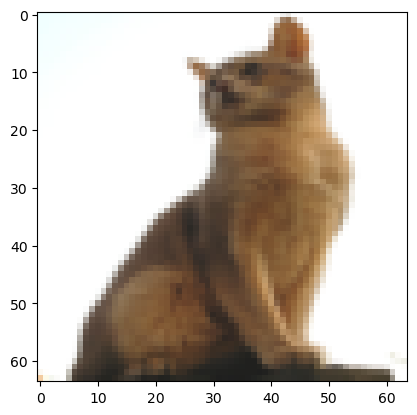

In [ ]:
index = 6
plt.imshow(test_set_x[:,index].reshape((64, 64 , 3)))
print ("y = " + str(test_set_y[0,index]) + ", предсказание нейросети: \"" + classes[int(d["Y_prediction_test"][0,index])].decode("utf-8") +  "\" на изображении.")

Построим график обучения сети: график зависимости функции стоимости от времени обучения

0.005


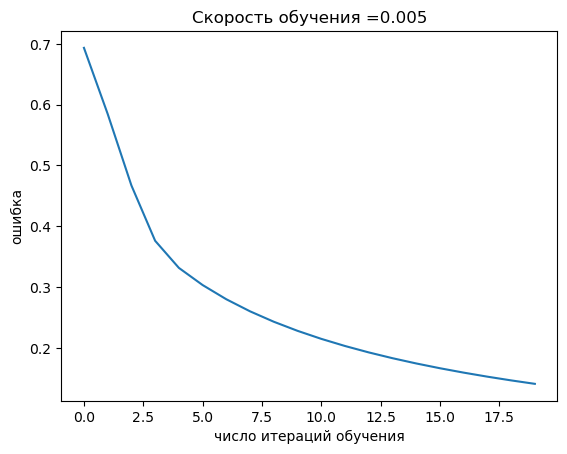

In [ ]:
costs = np.squeeze(d['costs'])
l_r = np.squeeze(d['learning_rate'])
print(l_r)
plt.plot(costs)
plt.ylabel('ошибка')
plt.xlabel('число итераций обучения')
plt.title("Скорость обучения =" + str(d["learning_rate"]))
plt.show()

Пояснение: график потерь в результате обучения стремиться к 0, что говорит о том, что модель обучается и все больше соотвествует данным. Однако с увеличением количества эпох обучения модель начинает подстраиваться под обучающие данные, "запоминать" тренировочный набор, однако это приводит зачастую к тому, что точность на тестовом наборе уменьшается. Выражаясь точнее, происходит переобучение: чрезмерная оптимизация на обучающих данных, что приводит к представлению, характерному для обучающих данных, не обобщающее данные за пределами обучающего набора.

**Задание 2.12**: Попробуйте увеличить количество итераций модели и перезапустите код обучения. Сравните точность обучения на тренировочном и тестовом наборе, сделайте выводы в ячейке ниже.

YOUR ANSWER HERE

## 6 - Настройка гиперпараметров ##

Установите экспериментально значение параметра скорости обучения модели, протестировав обучение с различными $\alpha$.

#### Выбор скорости обучения ####

**Пояснение**: для того, чтобы метод градиентого спуска приводил к оптимизации модели, а не расходился или застревал в локальных минимумах, следует осознано подбирать параметр скорости обучения. Скорость обучения $ \ alpha $ определяет, насколько быстро мы обновляем параметры. Если скорость обучения слишком велика, градиентный спуск может «перепрыгнуть» оптимальное значение. Точно так же, если скорость слишком мала, для обучения потребуется огромное число итераций. Вот почему важно обращать внимание на скорость обучения.

Сравните кривую обучения модели с несколькими вариантами скорости обучения и сделайте выводы. Не стесняйтесь также попробовать значения, отличные от заданных для переменной `learning_rates`.

learning rate is: 0.01
train accuracy: 100.0 %
test accuracy: 68.0 %

-------------------------------------------------------

learning rate is: 0.0015
train accuracy: 97.60765550239235 %
test accuracy: 70.0 %

-------------------------------------------------------

learning rate is: 0.001
train accuracy: 96.65071770334929 %
test accuracy: 74.0 %

-------------------------------------------------------



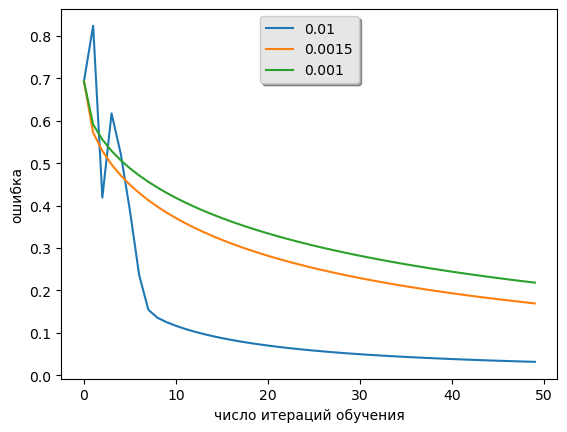

In [ ]:
learning_rates = [0.01, 0.0015, 0.001]
models = {}
for i in learning_rates:
    print ("learning rate is: " + str(i))
    models[str(i)] = model(train_set_x, train_set_y, test_set_x, test_set_y, num_iterations = 5000, learning_rate = i, print_cost = False)
    print ('\n' + "-------------------------------------------------------" + '\n')

for i in learning_rates:
    plt.plot(np.squeeze(models[str(i)]["costs"]), label= str(models[str(i)]["learning_rate"]))

plt.ylabel('ошибка')
plt.xlabel('число итераций обучения')

legend = plt.legend(loc='upper center', shadow=True)
frame = legend.get_frame()
frame.set_facecolor('0.90')
plt.show()

Напишите выводы о результатах обучения с различными значениями скорости обучения

YOUR ANSWER HERE

## 7 - Тестирование произвольных изображений ##

Вы можете использовать произвольные изображения для того, чтобы оценить полученную нейронную сеть.

Для этого:
   1. Загрузите изображение в директрию images данного Jupyter Notebook
   3. Измените переменную my_name на имя загруженного изображения
   4. Запустите ячейку кода и оцените результат (1 = cat, 0 = non-cat)!

y = 1, предсказание нейросети: "cat" на изображении.


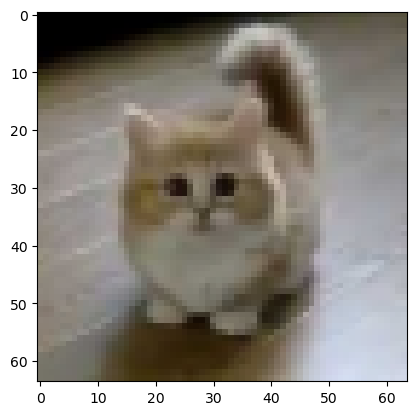

In [ ]:
from skimage import transform
from skimage.io import imread

num_py = 64
num_px = 64

"""my_image = Укажите имя вашего изображения в папке images"""
my_image = "my_image_cat.jpg"

# Загрузка указанного изображения
fname = "images/" + my_image
image = np.array(imread(fname))

# Предобработка и изменение размера изображения
image = image/255.
image = transform.resize(image, [num_py,num_px,3])
my_image = image.reshape((1, num_py*num_px*3)).T

my_predicted_image = predict(d["w"], d["b"], my_image)

plt.imshow(image)
print("y = " + str(np.squeeze(my_predicted_image)) + ", предсказание нейросети: \"" + classes[int(np.squeeze(my_predicted_image)),].decode("utf-8") +  "\" на изображении.")

Контрольные вопросы:
1. Что такое логистическая регрессия?

Логистическая регрессия - подвид линейной регрессии. Логистическая регрессия используется для решения задач классификации с линейно-разделяемыми классами. Иначе говоря, задача регрессии - попытаться востановить недостающие значения временного ряда или спрогнозировать его. Например, прогноз погоды и т.д.

2. Что такое нейронная сеть?

Нейронная сеть — это модель машинного обучения, состоящая из нейронов, расположенных слоями. Эти нейроны смоделированы по образцу нейронов нашего мозга и соединены друг с связями. Веса этих соединений корректируются в процессе обучения для получения более точных ответов сети.

3. Опишите работу функции np.squeeze().

Используется для удаления одномерных записей из формы массива. Функция `np.squeeze()` возвращает новый массив, в котором удалены все измерения размера 1. Если в массиве не найдены измерения размера 1, то исходный объект массива возвращается без каких-либо изменений.

4. Поясните, как зависят результаты обучения от заданной скорости обучения и количетсва итераций?

Скорость обучения определяет, насколько веса сети обновляются во время каждой итерации. Если скорость обучения слишком высока, обновления будут слишком большими, и сеть может не прийти к хорошему решению. С другой стороны, если скорость обучения слишком низкая, сеть может очень медленно сходиться и может застрять в локальных минимумах.

Количество итераций определяет, сколько раз сеть будет проходить обучающие данные (каждая итерация - 1 проход по всему объёму данных). Если количество итераций слишком мало, сети может не хватить времени, чтобы изучить все закономерности в данных. С другой стороны, если количество итераций слишком велико, сеть может начать переобучать обучающие данные, что означает, что она будет хорошо работать с обучающими данными, но плохо с новыми, невидимыми данными.

5. Что будет если скорость обучения сделать равной 0.5?

Нейросеть не выйдет в точку минимума (не найдёт её) и точность будет коллосально низкой, если же вопрос связан с кодом в ячейке 27, то результатом выполнения программы будет ряд ошибок, всвязи с делением на ноль в одной из формул.

***Литература:***


    1. Пережевывая логистическую регрессию: https://habr.com/ru/post/485872/abs